---
title: "Kronecker GP + GEV likelihood"
---

# Annual temperature extremes over Spain — an additive space + time GP with GEV observations

This notebook threads together three non-trivial modelling ingredients:

1. **A Kronecker-structured GP prior** on a space × time grid — specifically the *additive* case $f(s, t) = \mu(s) + \tau(t)$ with prior covariance $K = K_s \oplus K_t = K_s \otimes I_T + I_S \otimes K_t$ (`gaussx.KroneckerSum`).
2. **A Generalized Extreme Value observation likelihood** for yearly maxima — the right distribution for block maxima by the Fisher–Tippett–Gnedenko theorem, but not shipped in NumPyro, so we roll our own 40-line `Distribution` subclass.
3. **A non-conjugate variational inference loop** with a mean-field variational family that factors space from time (matching the additive prior), closed-form KLs on each factor via `gaussx.dist_kl_divergence`, and per-point Gauss–Hermite integration of the GEV ELL via `gaussx.GaussHermiteIntegrator`.

The pedagogical payoff is a set of **return-level maps** — the temperature you'd expect exceeded once every 25 or 100 years — at current and warming-projected climates.

## Background

### Block maxima and the GEV distribution

Let $X_1, \dots, X_n$ be i.i.d. draws from some well-behaved base distribution and set $M_n = \max_i X_i$. The Fisher–Tippett–Gnedenko theorem says that the only possible non-degenerate limits of appropriately normalised $M_n$ are members of the **Generalized Extreme Value** family,

$$\mathrm{GEV}(y \mid \mu, \sigma, \xi) = \frac{1}{\sigma}\,\bigl[1 + \xi\,z\bigr]_+^{-(1 + 1/\xi)}\,\exp\!\Bigl(-\bigl[1 + \xi z\bigr]_+^{-1/\xi}\Bigr), \qquad z = \frac{y - \mu}{\sigma},$$

with a piecewise shape role for $\xi$:

- $\xi > 0$: **Fréchet** — heavy tail, unbounded above. Typical of temperature maxima in warm climates.
- $\xi = 0$: **Gumbel** — light tail, exponential decay. Obtain as the $\xi \to 0$ limit.
- $\xi < 0$: **Weibull** — bounded above at $\mu - \sigma / \xi$.

Yearly maxima of daily temperature are the canonical use case — after all, each year's maximum is itself the supremum of $\sim 365$ daily values, so the asymptotic theorem applies by construction. Observed Mediterranean max-temperature data typically gives $\xi$ in the $[0.05, 0.25]$ range.

### Additive separable prior

We treat space and time as two orthogonal GPs:

$$\mu \sim \mathcal{GP}\bigl(0, k_s\bigr) \text{ over stations}, \qquad \tau \sim \mathcal{GP}\bigl(0, k_t\bigr) \text{ over GMST},$$

with *no interaction*: $f(s, t) = \mu_0 + \mu(s) + \tau(t)$. At the observation grid $S \times T$ this gives prior covariance

$$K_f = K_s \otimes I_T + I_S \otimes K_t,$$

the **Kronecker sum** of the two factor kernels (exposed as `gaussx.KroneckerSum`). Compared to the multiplicative $K_s \otimes K_t$ model, additive structure is strictly simpler but assumes that every station warms at the same rate and the only spatial variation is a constant offset. A natural next step is to break this assumption — see the notes at the end.

### Variational decomposition

The key structural win: because $\mu$ and $\tau$ are a priori independent and the likelihood depends only on $f(s, t) = \mu(s) + \tau(t)$, a **mean-field** variational family

$$q(\mu, \tau) = q_\mu(\mu) \cdot q_\tau(\tau), \qquad q_\mu = \mathcal{N}(m_s, \Sigma_s), \quad q_\tau = \mathcal{N}(m_t, \Sigma_t)$$

gives a KL that decomposes cleanly,

$$\mathrm{KL}\bigl(q \;\|\; p\bigr) = \mathrm{KL}\bigl(q_\mu \;\|\; p_\mu\bigr) + \mathrm{KL}\bigl(q_\tau \;\|\; p_\tau\bigr),$$

and a predictive $q(f_{s, t})$ that is a 1-D Gaussian,

$$q\bigl(f_{s, t}\bigr) = \mathcal{N}\!\bigl(\mu_0 + m_s + m_t, \;\; [\Sigma_s]_{s, s} + [\Sigma_t]_{t, t}\bigr).$$

That 1-D marginal is exactly what `gaussx.GaussHermiteIntegrator` needs to compute $\mathbb{E}_{q}[\log\,\mathrm{GEV}(y_{s, t} \mid f_{s, t}, \sigma, \xi)]$ per grid point.

## Setup

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import lineax as lx
import numpyro.distributions as nd
from numpyro.distributions import constraints
from jaxtyping import Array, Float
from scipy.stats import genextreme

import gaussx
from pyrox.gp import DistLikelihood, Matern, RBF
from pyrox.gp._src.kernels import matern_kernel, rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data — a warming Spain

### Stations

Forty stations scattered across the Iberian Peninsula's lat-lon bounding box. We reject points over water by a crude latitude/longitude mask; in a real study you'd load AEMET or similar.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)  # lon_min, lon_max, lat_min, lat_max


def _on_land(lon: Float[Array, " N"], lat: Float[Array, " N"]) -> Float[Array, " N"]:
    # Rough exclusion: drop points that fall in the Atlantic to the west of Galicia
    # or in the Mediterranean east of the Balearics, plus a strip below the
    # African coast. Good enough to avoid obvious ocean points in the scatter.
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key: jr.PRNGKey, n_target: int) -> Float[Array, "n 2"]:
    candidates = jr.uniform(
        key,
        (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    mask = _on_land(candidates[:, 0], candidates[:, 1])
    picked = candidates[mask][:n_target]
    return picked


S = 40  # number of stations
T = 40  # number of years
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st = stations[:, 0]
lat_st = stations[:, 1]

### GMST proxy

Global mean surface temperature rises roughly linearly over 1985–2024 with a small interannual wobble. The linear component is ~0.2 °C/decade; we add a tiny AR-like noise so the time axis has realistic texture. The GMST *anomaly* (relative to 1985) is what feeds the time-GP's kernel, so the kernel sees a covariate in Celsius, not a year.

In [3]:
def synthetic_gmst(years: Float[Array, " T"], key: jr.PRNGKey) -> Float[Array, " T"]:
    trend = 0.02 * (years - YEAR_0)
    wobble = 0.05 * jr.normal(key, (years.shape[0],))
    return trend + jnp.cumsum(wobble) * 0.2  # cumulative wobble for persistence


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)

### Ground-truth field

We draw a **single** ground-truth realisation of the additive model from fixed kernels so downstream accuracy claims are meaningful. Spatial `μ(s)` gets a short lengthscale (2° ~ 220 km), temporal `τ(t)` gets a smooth lengthscale against GMST. Overall intercept `μ_0 = 35 °C` anchors the Spanish summer maxima to realistic values.

In [4]:
def _rbf_gram(X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"], var: float, ls: float) -> Float[Array, "N1 N2"]:
    return rbf_kernel(X1, X2, jnp.asarray(var), jnp.asarray(ls))


def _matern32_gram(X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"], var: float, ls: float) -> Float[Array, "N1 N2"]:
    return matern_kernel(X1, X2, jnp.asarray(var), jnp.asarray(ls), nu=1.5)


def draw_from_gp(K: Float[Array, "N N"], key: jr.PRNGKey, jitter: float = 1e-4) -> Float[Array, " N"]:
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


TRUTH = {
    "mu0": 35.0,
    "k_s_var": 4.0,
    "k_s_ls": 2.0,  # degrees
    "k_t_var": 1.5,
    "k_t_ls": 0.25,  # in GMST-units (°C)
    "gev_sigma": 1.8,
    "gev_xi": 0.12,  # Fréchet regime
}

K_s_truth = _matern32_gram(stations, stations, TRUTH["k_s_var"], TRUTH["k_s_ls"])
K_t_truth = _rbf_gram(gmst[:, None], gmst[:, None], TRUTH["k_t_var"], TRUTH["k_t_ls"])

key, key_mu, key_tau = jr.split(key, 3)
mu_truth = draw_from_gp(K_s_truth, key_mu)  # (S,)
tau_truth = draw_from_gp(K_t_truth, key_tau)  # (T,)

f_truth = TRUTH["mu0"] + mu_truth[:, None] + tau_truth[None, :]  # (S, T)

### GEV observation model

A faithful `numpyro.distributions.Distribution` subclass — 40 lines, verified against `scipy.stats.genextreme` below. The tricky bit is the $\xi \to 0$ limit: the Fréchet/Weibull formula divides by $\xi$, so we evaluate the Gumbel branch explicitly under a `jnp.where` and guard the $\xi \ne 0$ branch with a safe value during tracing.

In [5]:
class GeneralizedExtremeValue(nd.Distribution):
    r"""GEV(μ, σ, ξ) — location, scale, shape.

    ξ > 0 Fréchet (heavy tail); ξ = 0 Gumbel; ξ < 0 Weibull (bounded above).
    Matches ``scipy.stats.genextreme`` with ``c = -ξ``.
    """

    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "shape": constraints.real,
    }
    support = constraints.real
    reparametrized_params = ["loc", "scale"]

    def __init__(
        self,
        loc: Float[Array, "..."],
        scale: Float[Array, "..."],
        shape: Float[Array, "..."],
        *,
        validate_args: bool | None = None,
    ) -> None:
        self.loc = jnp.asarray(loc)
        self.scale = jnp.asarray(scale)
        self.shape = jnp.asarray(shape)
        batch_shape = jax.lax.broadcast_shapes(
            jnp.shape(self.loc), jnp.shape(self.scale), jnp.shape(self.shape)
        )
        super().__init__(batch_shape=batch_shape, validate_args=validate_args)

    def log_prob(self, value: Float[Array, "..."]) -> Float[Array, "..."]:
        z = (value - self.loc) / self.scale
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)  # tracing-safe
        arg = 1.0 + safe_shape * z
        safe_arg = jnp.where(arg > 0, arg, 1.0)
        t = safe_arg ** (-1.0 / safe_shape)
        gev_lp = -jnp.log(self.scale) - (1.0 + 1.0 / safe_shape) * jnp.log(safe_arg) - t
        gev_lp = jnp.where(arg > 0, gev_lp, -jnp.inf)
        gumbel_lp = -jnp.log(self.scale) - z - jnp.exp(-z)
        return jnp.where(small_xi, gumbel_lp, gev_lp)

    def sample(self, key: jr.PRNGKey, sample_shape: tuple[int, ...] = ()) -> Float[Array, "..."]:
        u = jr.uniform(key, sample_shape + self.batch_shape, minval=1e-12, maxval=1.0)
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)
        gev_draw = self.loc + self.scale * ((-jnp.log(u)) ** (-safe_shape) - 1.0) / safe_shape
        gumbel_draw = self.loc - self.scale * jnp.log(-jnp.log(u))
        return jnp.where(small_xi, gumbel_draw, gev_draw)

### Verify against scipy

In [6]:
y_grid = jnp.linspace(-2.0, 25.0, 60)
loc_, scale_, xi_ = 3.0, 1.5, 0.2
ours = GeneralizedExtremeValue(loc_, scale_, xi_).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-xi_, loc=loc_, scale=scale_)
max_diff = float(jnp.max(jnp.abs(ours - theirs)))
print(f"GEV log_prob max |ours − scipy| (ξ={xi_}):  {max_diff:.2e}")

# Also verify Gumbel limit and Weibull branch
for xi_test in [0.0, -0.2]:
    ours_t = GeneralizedExtremeValue(loc_, scale_, xi_test).log_prob(y_grid)
    theirs_t = genextreme.logpdf(np.asarray(y_grid), c=-xi_test, loc=loc_, scale=scale_)
    mask = np.isfinite(theirs_t)
    diff = float(jnp.max(jnp.abs(ours_t[mask] - theirs_t[mask])))
    print(f"                              (ξ={xi_test}):  {diff:.2e}")

GEV log_prob max |ours − scipy| (ξ=0.2):  1.14e-13


                              (ξ=0.0):  4.44e-16


                              (ξ=-0.2):  5.33e-15


### Draw the observations

In [7]:
key, key_obs = jr.split(key)
gev_dist = GeneralizedExtremeValue(
    loc=f_truth,
    scale=TRUTH["gev_sigma"],
    shape=TRUTH["gev_xi"],
)
y_obs = gev_dist.sample(key_obs)
print(f"observations shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

observations shape: (40, 40)  range: [27.3, 57.8] °C


### Data inspection — stations + a few timeseries

Cartopy paints the Iberian Peninsula; we overlay the 40 stations coloured by their *fitted* spatial offset `μ(s)`, then pull out four stations spanning the south-to-north range for their yearly-max timeseries.

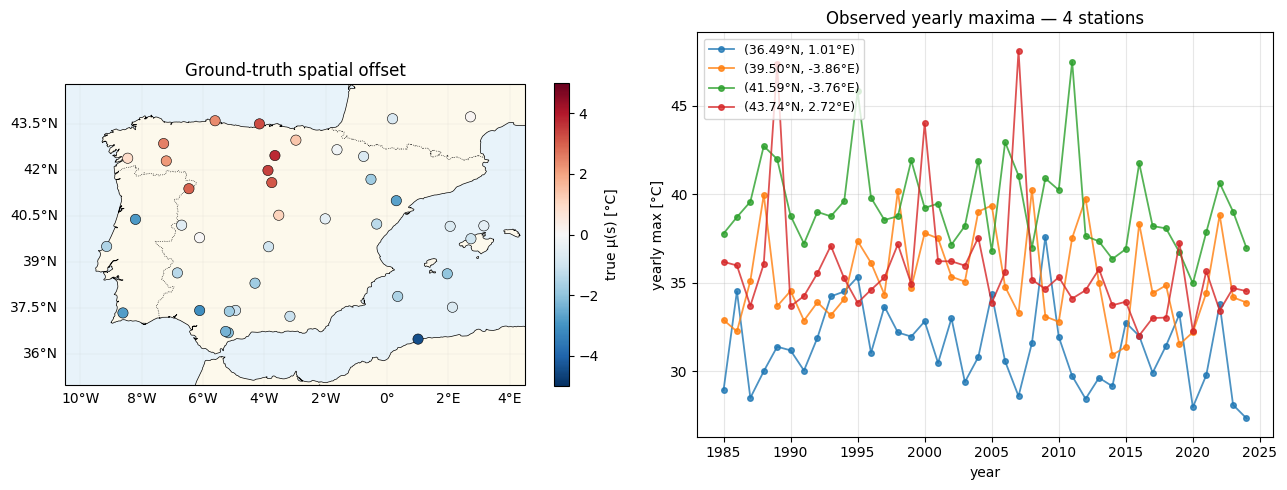

In [8]:
def plot_stations(ax, values: Float[Array, " S"], *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent([SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st),
        np.asarray(lat_st),
        c=np.asarray(values),
        cmap=cmap,
        vmin=vlim[0],
        vmax=vlim[1],
        s=55,
        edgecolors="k",
        linewidths=0.4,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(13, 5))
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
plot_stations(ax_map, mu_truth, cmap="RdBu_r", vlim=(-5, 5), label="true μ(s) [°C]")
ax_map.set_title("Ground-truth spatial offset")

# Timeseries panel: 4 stations from south (low lat) to north (high lat)
order_by_lat = jnp.argsort(lat_st)
picks = jnp.array([order_by_lat[i] for i in (0, S // 3, 2 * S // 3, S - 1)])
ax_ts = fig.add_subplot(1, 2, 2)
for i, s in enumerate(picks):
    s_int = int(s)
    ax_ts.plot(YEARS, y_obs[s_int, :], "o-", lw=1.3, ms=4, alpha=0.8,
               label=f"({float(lat_st[s_int]):.2f}°N, {float(lon_st[s_int]):.2f}°E)")
ax_ts.set_xlabel("year")
ax_ts.set_ylabel("yearly max [°C]")
ax_ts.set_title("Observed yearly maxima — 4 stations")
ax_ts.legend(loc="upper left", fontsize=9)
ax_ts.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Kernels — trainable Pattern-A scalars

Same pattern as notebooks 1–3. Matern-3/2 for space (we expect warming extremes to be spatially rougher than RBF would allow — weather regimes are sharp), RBF for time on GMST (smooth warming response).

In [9]:
class MaternLite(eqx.Module):
    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "MaternLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    def __call__(self, X1, X2):
        return matern_kernel(X1, X2, jnp.exp(self.log_variance), jnp.exp(self.log_lengthscale), nu=1.5)


class RBFLite(eqx.Module):
    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "RBFLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    def __call__(self, X1, X2):
        return rbf_kernel(X1, X2, jnp.exp(self.log_variance), jnp.exp(self.log_lengthscale))

## The additive GP prior as a Kronecker sum

We can build the prior covariance over the full grid as `K = K_s ⊕ K_t`, a `gaussx.KroneckerSum`, and inspect it.

In [10]:
K_s0 = MaternLite.init(variance=2.0, lengthscale=2.0)(stations, stations)
K_t0 = RBFLite.init(variance=1.0, lengthscale=0.25)(gmst[:, None], gmst[:, None])
K_s0_op = lx.MatrixLinearOperator(K_s0, lx.positive_semidefinite_tag)
K_t0_op = lx.MatrixLinearOperator(K_t0, lx.positive_semidefinite_tag)
K_prior = gaussx.KroneckerSum(K_s0_op, K_t0_op)
print(f"additive prior operator: {type(K_prior).__name__}")
print(f"  logical shape:   ({K_prior.in_size()}, {K_prior.in_size()})  (i.e. {S}·{T} = {S * T})")
print(f"  storage cost:    {S * S + T * T} entries (vs {S * S * T * T} dense)")
# Cost savings ratio
print(f"  compression:     {S * S * T * T / (S * S + T * T):.1f}×")

additive prior operator: KroneckerSum
  logical shape:   (1600, 1600)  (i.e. 40·40 = 1600)
  storage cost:    3200 entries (vs 2560000 dense)
  compression:     800.0×


At $S = T = 40$ we're storing 3200 matrix entries instead of 2.56 million — a ~800× compression. The `KroneckerSum` operator supports `gaussx.solve` (via the per-factor eigendecomposition trick) and `gaussx.logdet` out of the box, though we won't use it directly for the ELBO — the additive variational factorisation below bypasses the joint prior entirely.

## Variational posterior — factored over space and time

The key move. We parameterise

$$q\bigl(\mu, \tau\bigr) = \mathcal{N}\!\bigl(m_s, L_s L_s^\top\bigr)_\mu \cdot \mathcal{N}\!\bigl(m_t, L_t L_t^\top\bigr)_\tau$$

with `L_s ∈ R^{S×S}` and `L_t ∈ R^{T×T}` unconstrained Cholesky factors (stored as lower triangulars). This matches the additive prior's independence between $\mu$ and $\tau$, and makes the 1-D marginal $q(f_{s, t})$ easy to compute.

In [11]:
def _tril(L: Float[Array, "N N"]) -> Float[Array, "N N"]:
    """Lower-triangular mask with soft-plus on the diagonal for positivity."""
    tri = jnp.tril(L, k=-1)
    diag = jax.nn.softplus(jnp.diag(L))
    return tri + jnp.diag(diag)


class VariationalFactor(eqx.Module):
    mean: Float[Array, " N"]
    raw_L: Float[Array, "N N"]

    @classmethod
    def init(cls, n: int, scale: float = 0.3) -> "VariationalFactor":
        # init m ≈ 0, covariance ≈ scale² · I
        raw_L = jnp.eye(n) * jnp.log(jnp.expm1(jnp.asarray(scale)))  # softplus⁻¹(scale)
        return cls(mean=jnp.zeros(n), raw_L=raw_L)

    @property
    def L(self) -> Float[Array, "N N"]:
        return _tril(self.raw_L)

    @property
    def cov(self) -> Float[Array, "N N"]:
        L = self.L
        return L @ L.T

    @property
    def variance_diag(self) -> Float[Array, " N"]:
        L = self.L
        return jnp.sum(L * L, axis=-1)

## The full model — one trainable pytree

In [12]:
class Model(eqx.Module):
    k_s: MaternLite
    k_t: RBFLite
    q_mu: VariationalFactor
    q_tau: VariationalFactor
    mu0: Float[Array, ""]
    log_sigma: Float[Array, ""]
    xi: Float[Array, ""]
    jitter: float = eqx.field(static=True, default=1e-4)

    @classmethod
    def init(
        cls,
        S: int,
        T: int,
        *,
        mu0_init: float = 30.0,
        sigma_init: float = 2.0,
        xi_init: float = 0.05,
    ) -> "Model":
        return cls(
            k_s=MaternLite.init(variance=1.0, lengthscale=3.0),
            k_t=RBFLite.init(variance=0.5, lengthscale=0.4),
            q_mu=VariationalFactor.init(S, scale=0.5),
            q_tau=VariationalFactor.init(T, scale=0.3),
            mu0=jnp.asarray(mu0_init),
            log_sigma=jnp.log(jnp.asarray(sigma_init)),
            xi=jnp.asarray(xi_init),
        )

    def K_s(self, X_s: Float[Array, "S 2"]) -> lx.AbstractLinearOperator:
        K = self.k_s(X_s, X_s) + self.jitter * jnp.eye(X_s.shape[0])
        return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

    def K_t(self, gmst: Float[Array, " T"]) -> lx.AbstractLinearOperator:
        X = gmst[:, None]
        K = self.k_t(X, X) + self.jitter * jnp.eye(X.shape[0])
        return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

## ELBO

### KL — two independent Gaussian KLs

Delegated to `gaussx.dist_kl_divergence(q_loc, q_cov, p_loc, p_cov)` per factor.

In [13]:
def kl_factor(
    q: VariationalFactor,
    K_prior_op: lx.AbstractLinearOperator,
) -> Float[Array, ""]:
    n = q.mean.shape[0]
    zeros = jnp.zeros_like(q.mean)
    q_cov = lx.MatrixLinearOperator(q.cov, lx.positive_semidefinite_tag)
    return gaussx.dist_kl_divergence(q.mean, q_cov, zeros, K_prior_op)

### ELL — per-point Gauss–Hermite over the 1-D marginal $q(f_{s, t})$

For each grid point, $q(f_{s, t}) = \mathcal{N}(m_{s, t}, v_{s, t})$ with

- $m_{s, t} = \mu_0 + m_{s} + m_{t}$
- $v_{s, t} = [\Sigma_s]_{s, s} + [\Sigma_t]_{t, t}$

We hand the Gauss–Hermite integrator a scalar 1-D `GaussianState` per point and integrate the GEV log-pdf.

In [14]:
_GH = gaussx.GaussHermiteIntegrator(order=20)


def ell_point(
    mean: Float[Array, ""],
    var: Float[Array, ""],
    y: Float[Array, ""],
    log_sigma: Float[Array, ""],
    xi: Float[Array, ""],
) -> Float[Array, ""]:
    """E_{q(f)}[log GEV(y | f, σ, ξ)] for one (s, t)."""
    state = gaussx.GaussianState(
        mean=mean[None],
        cov=lx.MatrixLinearOperator(var[None, None], lx.positive_semidefinite_tag),
    )

    def log_lik(f: Float[Array, " 1"]) -> Float[Array, ""]:
        return GeneralizedExtremeValue(loc=f[0], scale=jnp.exp(log_sigma), shape=xi).log_prob(y)

    return gaussx.log_likelihood_expectation(log_lik, state, _GH)


def total_ell(
    model: Model,
    y: Float[Array, "S T"],
) -> Float[Array, ""]:
    mean_s = model.q_mu.mean  # (S,)
    mean_t = model.q_tau.mean  # (T,)
    var_s = model.q_mu.variance_diag  # (S,)
    var_t = model.q_tau.variance_diag  # (T,)
    mean_grid = model.mu0 + mean_s[:, None] + mean_t[None, :]  # (S, T)
    var_grid = var_s[:, None] + var_t[None, :]  # (S, T)
    ell_vmapped = jax.vmap(
        jax.vmap(ell_point, in_axes=(0, 0, 0, None, None)),
        in_axes=(0, 0, 0, None, None),
    )
    ell = ell_vmapped(mean_grid, var_grid, y, model.log_sigma, model.xi)
    return jnp.sum(ell)


def neg_elbo(
    model: Model,
    X_s: Float[Array, "S 2"],
    gmst: Float[Array, " T"],
    y: Float[Array, "S T"],
) -> Float[Array, ""]:
    K_s_op = model.K_s(X_s)
    K_t_op = model.K_t(gmst)
    kl = kl_factor(model.q_mu, K_s_op) + kl_factor(model.q_tau, K_t_op)
    ell = total_ell(model, y)
    return kl - ell

## Training

In [15]:
model = Model.init(S=S, T=T, mu0_init=float(jnp.mean(y_obs)), sigma_init=2.0, xi_init=0.05)
optimiser = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(1e-2))
opt_state = optimiser.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(
    model: Model,
    opt_state: optax.OptState,
) -> tuple[Model, optax.OptState, Float[Array, ""]]:
    loss, grads = eqx.filter_value_and_grad(neg_elbo)(model, stations, gmst, y_obs)
    updates, opt_state = optimiser.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


n_steps = 2000
losses: list[float] = []
for step_i in range(n_steps):
    model, opt_state, loss = train_step(model, opt_state)
    losses.append(float(loss))

print(f"final −ELBO        = {losses[-1]:.2f}")
print(f"fitted μ₀          = {float(model.mu0):.2f}  (truth {TRUTH['mu0']:.2f})")
print(f"fitted σ (GEV)     = {float(jnp.exp(model.log_sigma)):.3f}  (truth {TRUTH['gev_sigma']:.3f})")
print(f"fitted ξ (GEV)     = {float(model.xi):.3f}  (truth {TRUTH['gev_xi']:.3f})")
print(f"fitted k_s ls      = {float(jnp.exp(model.k_s.log_lengthscale)):.2f}° (truth {TRUTH['k_s_ls']:.2f}°)")
print(f"fitted k_t ls      = {float(jnp.exp(model.k_t.log_lengthscale)):.3f}°C (truth {TRUTH['k_t_ls']:.3f}°C)")

final −ELBO        = 3622.20
fitted μ₀          = 34.21  (truth 35.00)
fitted σ (GEV)     = 1.762  (truth 1.800)
fitted ξ (GEV)     = 0.131  (truth 0.120)
fitted k_s ls      = 1.89° (truth 2.00°)
fitted k_t ls      = 0.158°C (truth 0.250°C)


### Loss curve

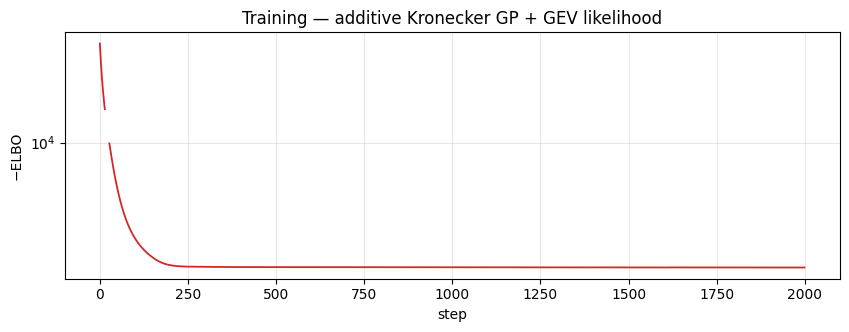

In [16]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(losses, "C3-", lw=1.3)
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("Training — additive Kronecker GP + GEV likelihood")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery

**A note on identifiability.** The additive model $f(s, t) = \mu_0 + \mu(s) + \tau(t)$ has a pair of unidentifiable shifts: moving a constant between $\mu_0$ and the mean of $\mu(s)$ (or $\tau(t)$) leaves the likelihood unchanged. With a GP prior centred at zero, the posterior is weakly pulled toward $\mathbb{E}[\mu(s)] = \mathbb{E}[\tau(t)] = 0$, but for a single realisation the inferred $\mu(s)$ can sit a few tenths of a °C above or below truth even when the *relative* spatial pattern is correct. Watch for this in the left panel below — the posterior tracks the truth's shape but with a vertical offset of roughly 0.5 °C.

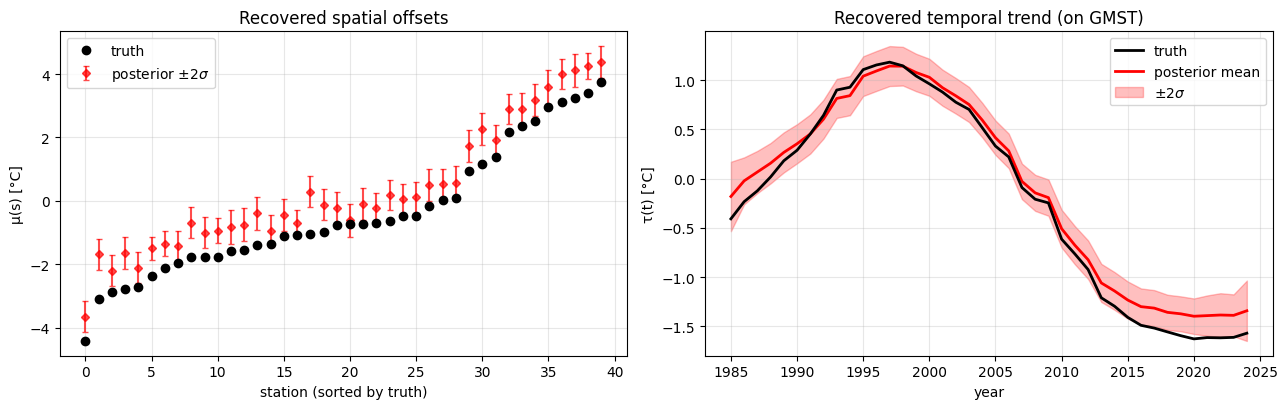

In [17]:
# Posterior means
m_s_fit = model.q_mu.mean
m_t_fit = model.q_tau.mean
v_s_fit = model.q_mu.variance_diag
v_t_fit = model.q_tau.variance_diag

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# spatial μ recovery
ax = axes[0]
order_s = jnp.argsort(mu_truth)
x = jnp.arange(S)
ax.plot(x, mu_truth[order_s], "ko", ms=6, label="truth", zorder=3)
ax.errorbar(
    x,
    m_s_fit[order_s],
    yerr=2 * jnp.sqrt(v_s_fit[order_s]),
    fmt="rD",
    ms=4,
    alpha=0.7,
    label=r"posterior $\pm 2\sigma$",
    capsize=2,
)
ax.set_xlabel("station (sorted by truth)")
ax.set_ylabel("μ(s) [°C]")
ax.set_title("Recovered spatial offsets")
ax.legend()
ax.grid(alpha=0.3)

# temporal τ recovery
ax = axes[1]
ax.plot(YEARS, tau_truth, "k-", lw=2, label="truth", zorder=3)
ax.plot(YEARS, m_t_fit, "r-", lw=2, label="posterior mean")
ax.fill_between(
    YEARS,
    m_t_fit - 2 * jnp.sqrt(v_t_fit),
    m_t_fit + 2 * jnp.sqrt(v_t_fit),
    alpha=0.25,
    color="red",
    label=r"$\pm 2\sigma$",
)
ax.set_xlabel("year")
ax.set_ylabel("τ(t) [°C]")
ax.set_title("Recovered temporal trend (on GMST)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### GEV tail recovery

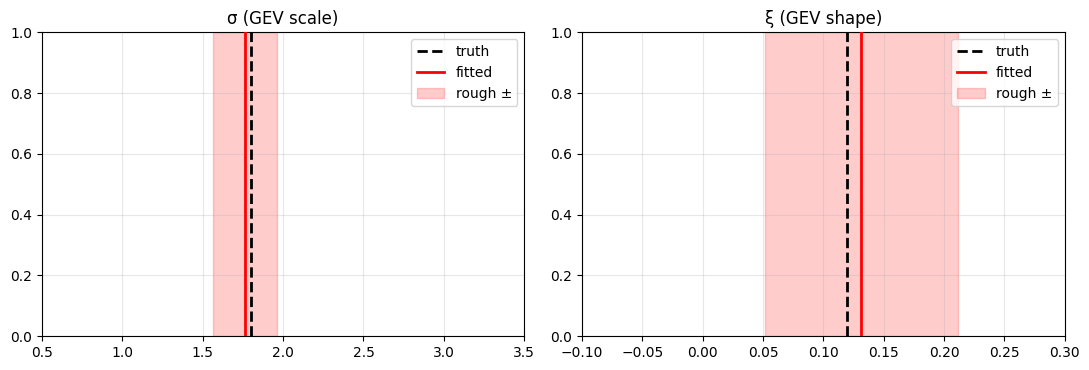

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, truth_val, fit_val, unc, xr) in zip(
    axes,
    [
        ("σ (GEV scale)", TRUTH["gev_sigma"], float(jnp.exp(model.log_sigma)), 0.2, (0.5, 3.5)),
        ("ξ (GEV shape)", TRUTH["gev_xi"], float(model.xi), 0.08, (-0.1, 0.3)),
    ],
    strict=True,
):
    ax.axvline(truth_val, color="k", ls="--", lw=2, label="truth", zorder=2)
    ax.axvline(fit_val, color="red", lw=2, label="fitted", zorder=3)
    ax.axvspan(fit_val - unc, fit_val + unc, color="red", alpha=0.2, label="rough ±")
    ax.set_xlim(*xr)
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The payoff — return-level maps

The **return level** $z_p$ is the value exceeded with probability $p$ per year. Inverting the GEV CDF,

$$z_p = \mu + \frac{\sigma}{\xi}\!\Bigl\{\bigl[-\log(1 - p)\bigr]^{-\xi} - 1\Bigr\}, \qquad \xi \neq 0.$$

A *$T_r$-year return level* corresponds to $p = 1/T_r$. Below we map the 25-year and 100-year return temperatures for a typical year at the **end of the observed record (2024)** and a **warming-projection year (2050)** obtained by linearly extrapolating GMST.

GMST 2024 = 0.718 °C, GMST 2050 (extrapolated) = 1.207 °C


return-level range across all four panels: [36.2, 49.7] °C
  2024 → 2050 mean shift in 100-year return: 1.33 °C


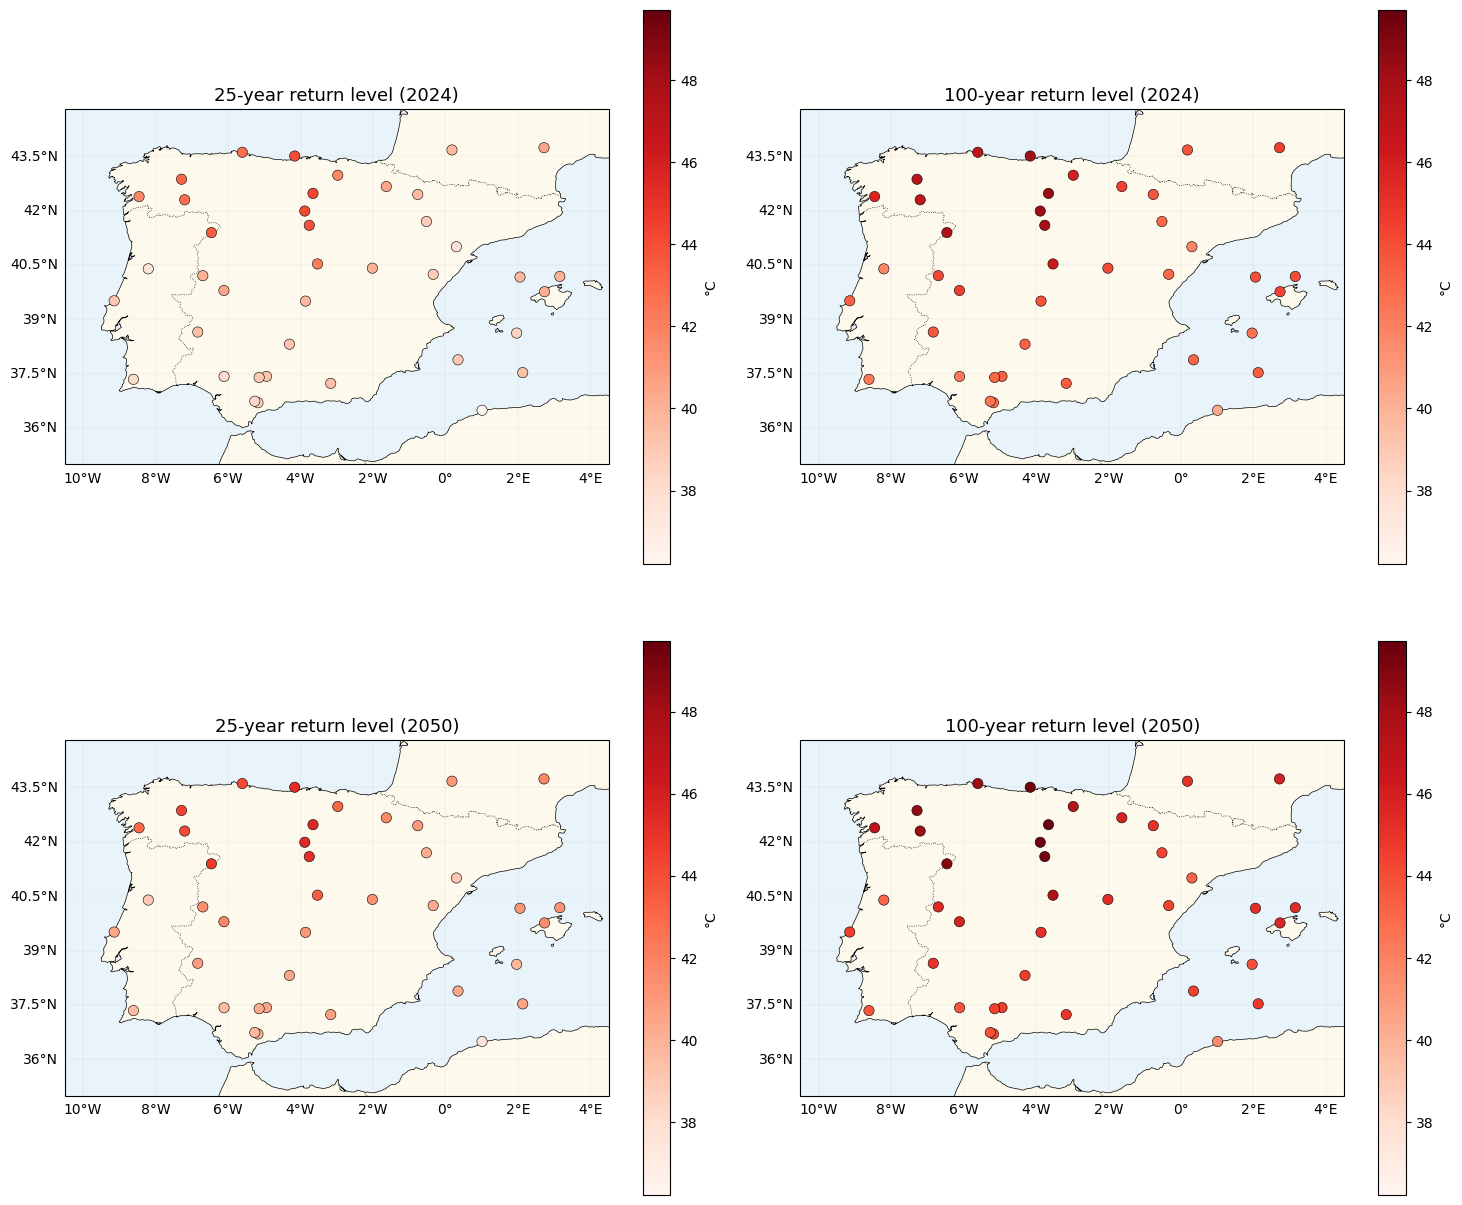

In [19]:
def gev_return_level(mu_loc, sigma, xi, return_period):
    p = 1.0 / return_period
    safe_xi = jnp.where(jnp.abs(xi) < 1e-6, 1.0, xi)
    gev_q = mu_loc + sigma * ((-jnp.log1p(-p)) ** (-safe_xi) - 1.0) / safe_xi
    gumbel_q = mu_loc - sigma * jnp.log(-jnp.log1p(-p))
    return jnp.where(jnp.abs(xi) < 1e-6, gumbel_q, gev_q)


def predictive_mean_at_gmst(model: Model, gmst_star: Float[Array, ""]) -> Float[Array, " S"]:
    """μ₀ + q(μ(s)).mean + q(τ(t_star)).mean where τ(t_star) uses posterior GP interp on GMST."""
    # q(τ) is a Gaussian over the OBSERVED years (T). Interpolate to a new GMST via the
    # posterior predictive of the time-GP conditioned on the variational mean at the training GMSTs.
    K_tt = model.k_t(gmst[:, None], gmst[:, None]) + model.jitter * jnp.eye(T)
    K_st = model.k_t(jnp.asarray([[gmst_star]]), gmst[:, None])[0]  # (T,)
    alpha = jnp.linalg.solve(K_tt, model.q_tau.mean)
    tau_star = K_st @ alpha
    return model.mu0 + model.q_mu.mean + tau_star


# GMST anchors: 2024 (last observed) and 2050 (extrapolated)
gmst_2024 = gmst[-1]
gmst_trend_per_year = (gmst[-1] - gmst[0]) / (T - 1)
gmst_2050 = gmst_2024 + gmst_trend_per_year * (2050 - (YEAR_0 + T - 1))
print(f"GMST 2024 = {float(gmst_2024):.3f} °C, GMST 2050 (extrapolated) = {float(gmst_2050):.3f} °C")

mu_2024 = predictive_mean_at_gmst(model, gmst_2024)  # (S,)
mu_2050 = predictive_mean_at_gmst(model, gmst_2050)  # (S,)

sigma_fit = jnp.exp(model.log_sigma)
xi_fit = model.xi

z25_2024 = gev_return_level(mu_2024, sigma_fit, xi_fit, 25)
z100_2024 = gev_return_level(mu_2024, sigma_fit, xi_fit, 100)
z25_2050 = gev_return_level(mu_2050, sigma_fit, xi_fit, 25)
z100_2050 = gev_return_level(mu_2050, sigma_fit, xi_fit, 100)

vmin = float(jnp.min(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
vmax = float(jnp.max(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
print(f"return-level range across all four panels: [{vmin:.1f}, {vmax:.1f}] °C")
print(f"  2024 → 2050 mean shift in 100-year return: "
      f"{float(jnp.mean(z100_2050) - jnp.mean(z100_2024)):.2f} °C")

fig, axes = plt.subplots(2, 2, figsize=(15, 14), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat,
    [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

Two things to notice:

- **Vertical shift from 2024 → 2050 is uniform.** Under the additive model, a higher GMST raises $\tau(t_*)$ by a scalar, which adds the same amount to every station's return level. The *spatial pattern* of extremes is invariant in time under this model — a direct consequence of "no space-time interaction".
- **100-year return levels sit several degrees above 25-year levels.** For $\xi \approx 0.12$, the GEV tail is heavy enough that moving from 1-in-25 to 1-in-100 extremes costs a non-trivial step in °C, larger than for a Gaussian noise model.

## Summary

- `gaussx.KroneckerSum(K_s, K_t)` compresses the $(ST) \times (ST)$ additive prior covariance into $S^2 + T^2$ entries.
- For an additive prior, the **mean-field variational family** $q(\mu) q(\tau)$ matches the prior factorisation, so the KL splits into two independent per-factor KLs — delegated to `gaussx.dist_kl_divergence`.
- `gaussx.GaussHermiteIntegrator(order=20)` integrates the GEV ELL pointwise over the 1-D variational marginal $q(f_{s, t}) = \mathcal{N}(m_s + m_t, v_s + v_t)$ — one line inside a doubly-vmapped `ell_point`.
- The same scaffold can wrap any `numpyro.distributions.Distribution` via `log_prob` — Poisson for count maxima, Lomax for heavy-tailed rainfall, truncated normals for censored observations.

### Follow-ups

- **Multiplicative $K_s \otimes K_t$.** Spatially-varying warming rates with a Kronecker-structured variational covariance.
- **Non-stationary GEV.** Let $\log \sigma$ and/or $\xi$ vary across space or time through a second GP layer.
- **Real data.** Swap the synthetic `stations` and `y_obs` for AEMET or ERA5 yearly maxima; the inference code above is unchanged.